To rerun the training process from scratch, delete the folders model, feature_store, and delete the files train_embeddings.csv, interaction_heatmap.png, and transformer.pth

Accordingly move datasets into the data folder depending on what data you want to test/train on, and name them test.csv and train.csv respectively

In [1]:
%%time
!python generate_features.py

Beginning feature generation based on train/test split...
Total unique molecules to process: 732 solutes, 128 solvents.
Solute Raw Features already exist.
Solvent Raw Features already exist.

Determining Training Distribution to FIT the Council Extractor...
Council Extractor fitted on distribution defined by top 19 solvents.
Transforming ALL molecules into Council Features...
Generated all required feature stores for the entire dataset, scaled using only the training distribution.
CPU times: user 20.4 ms, sys: 14.4 ms, total: 34.9 ms
Wall time: 2.74 s


In [2]:
%%time
!python train_transformer.py

Starting 5-Fold OOF Training on mps...
Training on Fold 1: 100%|███████████████████████| 20/20 [01:00<00:00,  3.02s/it]
  Fold 1 complete.
Training on Fold 2: 100%|███████████████████████| 20/20 [01:00<00:00,  3.02s/it]
  Fold 2 complete.
Training on Fold 3: 100%|███████████████████████| 20/20 [00:59<00:00,  2.97s/it]
  Fold 3 complete.
Training on Fold 4: 100%|███████████████████████| 20/20 [01:00<00:00,  3.04s/it]
  Fold 4 complete.
Training on Fold 5: 100%|███████████████████████| 20/20 [00:59<00:00,  2.98s/it]
  Fold 5 complete.
Training Final Production Model...
Final Pass: 100%|███████████████████████████████| 20/20 [01:15<00:00,  3.78s/it]
Success: train_embeddings.csv, transformer.pth, and interaction_heatmap.png saved.
CPU times: user 2.14 s, sys: 787 ms, total: 2.93 s
Wall time: 6min 46s


In [3]:
%%time
!python train.py

Training model
Initial features: 380
Pruned features:  289
Physical consistency maintained

TRAINING WITH 5 SEEDS

--- Seed 42 ---
0:	learn: 1.1583031	test: 1.1605958	best: 1.1605958 (0)	total: 117ms	remaining: 5m 52s
500:	learn: 0.4507225	test: 0.4662884	best: 0.4662884 (500)	total: 25.1s	remaining: 2m 4s
1000:	learn: 0.3219639	test: 0.3376208	best: 0.3376208 (1000)	total: 49.9s	remaining: 1m 39s
1500:	learn: 0.2648303	test: 0.2806727	best: 0.2806727 (1500)	total: 1m 17s	remaining: 1m 17s
2000:	learn: 0.2325318	test: 0.2484040	best: 0.2484040 (2000)	total: 1m 51s	remaining: 55.9s
2500:	learn: 0.2129926	test: 0.2283138	best: 0.2283138 (2500)	total: 2m 23s	remaining: 28.7s
2999:	learn: 0.2013678	test: 0.2177951	best: 0.2177890 (2998)	total: 2m 53s	remaining: 0us

bestTest = 0.2177889675
bestIteration = 2998

Shrink model to first 2999 iterations.
  RMSE: 0.6785, R²: 0.6574

--- Seed 101 ---
0:	learn: 1.1583057	test: 1.1651718	best: 1.1651718 (0)	total: 56.1ms	remaining: 2m 48s
500:	lear

In [4]:
%%time
!python eval_test.py

Evaluation testing
Loading model artifacts...
Generating learned interactions for 9137 molecules...
Applying Thermodynamic Engineering...
Performing final predictions...

Test Results
RMSE: 0.6745
R2: 0.6615
Inference timing results:
Total Time: 0.4714 s
Throughput: 19385 pairs/sec
CPU times: user 27.5 ms, sys: 15.6 ms, total: 43.1 ms
Wall time: 4.65 s


In [1]:
!python ablations.py

GLASS ONION ABLATION STUDY

Loading data and features...

Total features: 380
x_A: 0-176 (176 features)
x_B: 176-352 (176 features)
I: 352-376 (24 features)
f(T): 376-380 (4 features: Tm, T_red, T, T_inv)

BASELINE VARIANCE ESTIMATION (5 seeds)
  Seed 42... R²=0.6574, RMSE=0.6785
  Seed 101... R²=0.6577, RMSE=0.6782
  Seed 123... R²=0.6615, RMSE=0.6745
  Seed 456... R²=0.6576, RMSE=0.6783
  Seed 789... R²=0.6541, RMSE=0.6818

  BASELINE: R² = 0.6577 ± 0.0023, RMSE = 0.6783 ± 0.0023

Experiment: FULL MODEL (380 features)
Features: 380 / 380
After variance pruning: 289
0:	learn: 1.1594058	test: 1.1457919	best: 1.1457919 (0)	total: 133ms	remaining: 6m 38s
200:	learn: 0.6167015	test: 0.6254243	best: 0.6254243 (200)	total: 13.4s	remaining: 3m 6s
400:	learn: 0.4897180	test: 0.4996734	best: 0.4996734 (400)	total: 26s	remaining: 2m 48s
600:	learn: 0.4157610	test: 0.4272452	best: 0.4272452 (600)	total: 44.6s	remaining: 2m 58s
800:	learn: 0.3630478	test: 0.3739383	best: 0.3739383 (800)	total: 1m

# Hyperparameter sweep

BigSol 1.0

In [1]:
!python hyperparam_sweep.py

HYPERPARAMETER OPTIMIZATION - CATBOOST
Trials: 10, Validation Split: 15%

[1] Loading train CSV...
  Loaded 38540 rows
  Loading OOF embeddings...
  Loaded OOF: 38540 rows
  Generating hyper features (this may take a while)...
  DONE! Feature dim: (38540, 380)
  Train samples: 38540
  Feature dim: 380

[2] Applying feature selection...
  Loading selector...
  Transforming features...
  Selected features: 282

[3] Running Optuna optimization with 5-fold CV...
  (Each trial runs 5 folds, ~10 min per trial)
[I 2026-01-19 15:24:04,201] A new study created in memory with name: no-name-c632ce5b-7127-422a-948a-db056b56a1a6
  0%|                                                    | 0/10 [00:00<?, ?it/s]
>>> Trial 0: depth=9, iter=3500, lr=0.0896
  Fold 1/5: RMSE=0.1932
  Fold 2/5: RMSE=0.1898
  Fold 3/5: RMSE=0.2019
  Fold 4/5: RMSE=0.1972
  Fold 5/5: RMSE=0.2043
  Mean CV RMSE: 0.1973
[I 2026-01-19 15:36:35,221] Trial 0 finished with value: 0.19729140605817 and parameters: {'iterations': 3500

TRANSFORMER BENEFIT CASE ANALYSIS

ANGLE 1: DATA-SCARCE SOLVENTS

Small sample solvents (Count ≤ 30): n = 38
  Mean ΔRMSE: -0.000853
  Median ΔRMSE: -0.004279
  Std ΔRMSE: 0.039317

Large sample solvents (Count > 30): n = 53
  Mean ΔRMSE: -0.006349
  Median ΔRMSE: -0.002029
  Std ΔRMSE: 0.035961

Mann-Whitney U test (small > large): U = 1065.00, p = 0.3218
Independent t-test: t = 0.691, p = 0.4911

Positive improvements (ΔRMSE > 0):
  Small sample: 17/38 (44.7%)
  Large sample: 24/53 (45.3%)

ANGLE 2: MULTIFUNCTIONAL SOLVENTS

Multifunctional solvents (≥3 heteroatoms): n = 13
  Mean ΔRMSE: -0.008870
  Median ΔRMSE: -0.017624

Simple solvents (<3 heteroatoms): n = 78
  Mean ΔRMSE: -0.003252
  Median ΔRMSE: -0.001794

Mann-Whitney U test (multifunctional > simple): U = 433.00, p = 0.8009

Top 5 Multifunctional Improvers:
                   Name                Solvent  Delta_RMSE  Pct_Improvement  n_heteroatoms_simple  Count
   COC(C)COC(C)COC(C)CO   COC(C)COC(C)COC(C)CO    0.127064      

/var/folders/97/byfq9c_s4_7436j911y4dmm00000gn/T/ipykernel_40716/2053347468.py:134: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  difficult['absolute_improvement'] = difficult['RMSE_Without'] - difficult['RMSE_With']
/var/folders/97/byfq9c_s4_7436j911y4dmm00000gn/T/ipykernel_40716/2053347468.py:135: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  easy['absolute_improvement'] = easy['RMSE_Without'] - easy['RMSE_With']


Saved: transformer_benefit_analysis.png
Saved: sample_count_vs_improvement.png

Generating molecular structure figure...
Saved: top_improver_structures.png

SUMMARY TABLE (LaTeX)

\begin{table}[htbp]
\centering
\caption{Transformer Benefit Across Different Solvent Regimes}
\label{tab:transformer_regimes}
\begin{tabular}{lcccc}
\toprule
Regime & N & Mean $\Delta$RMSE & Median $\Delta$RMSE & p-value \\
       & Solvents & (logS) & (logS) & (vs. complement) \\
\midrule
Data-Scarce (n≤30) & 38 & -0.0009 & -0.0043 & 0.322 \\
Data-Rich (n>30) & 53 & -0.0063 & -0.0020 & — \\
Multifunctional (≥3 heteroatoms) & 13 & -0.0089 & -0.0176 & 0.801 \\
Simple (<3 heteroatoms) & 78 & -0.0033 & -0.0018 & — \\
Difficult (high baseline error) & 23 & +0.0040 & -0.0042 & 0.220 \\
Easy (low baseline error) & 68 & -0.0068 & -0.0021 & — \\
\bottomrule
\end{tabular}
\end{table}


Saved: transformer_regimes_table.tex

Saved: transformer_analysis_enhanced.csv

ANALYSIS COMPLETE - KEY FINDINGS

✓ ANGLE 1 (Data-Scar

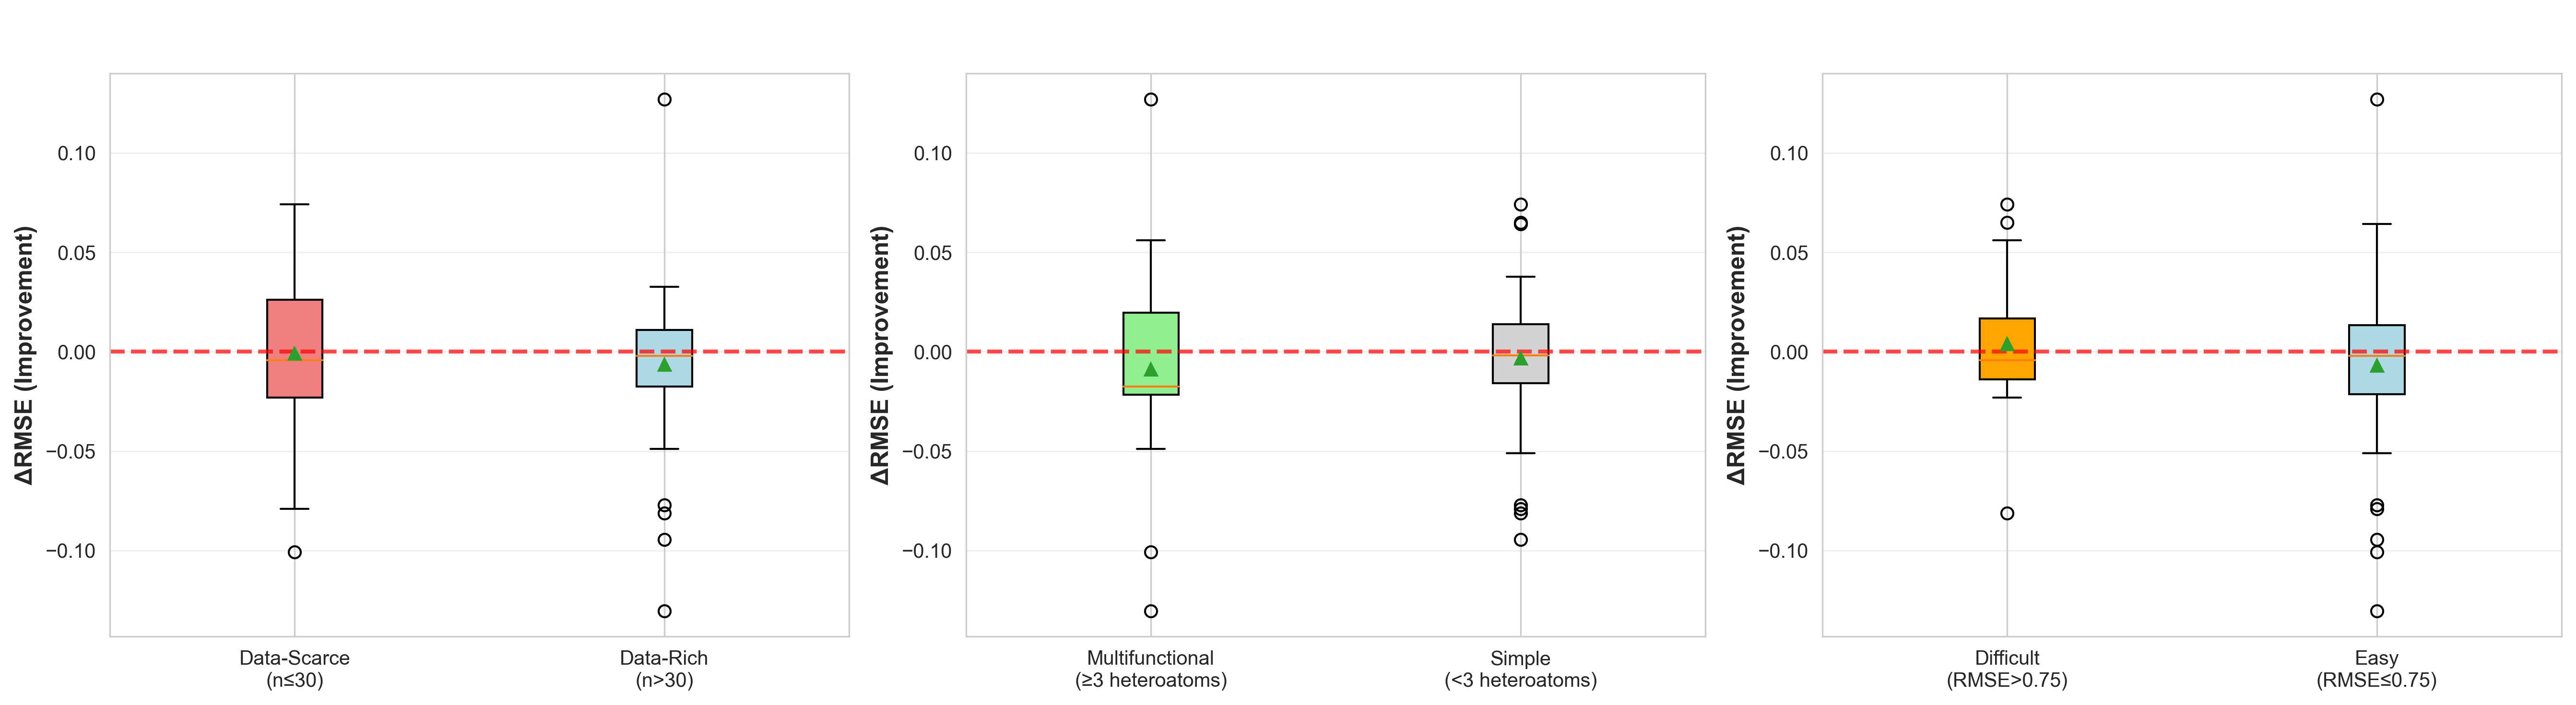

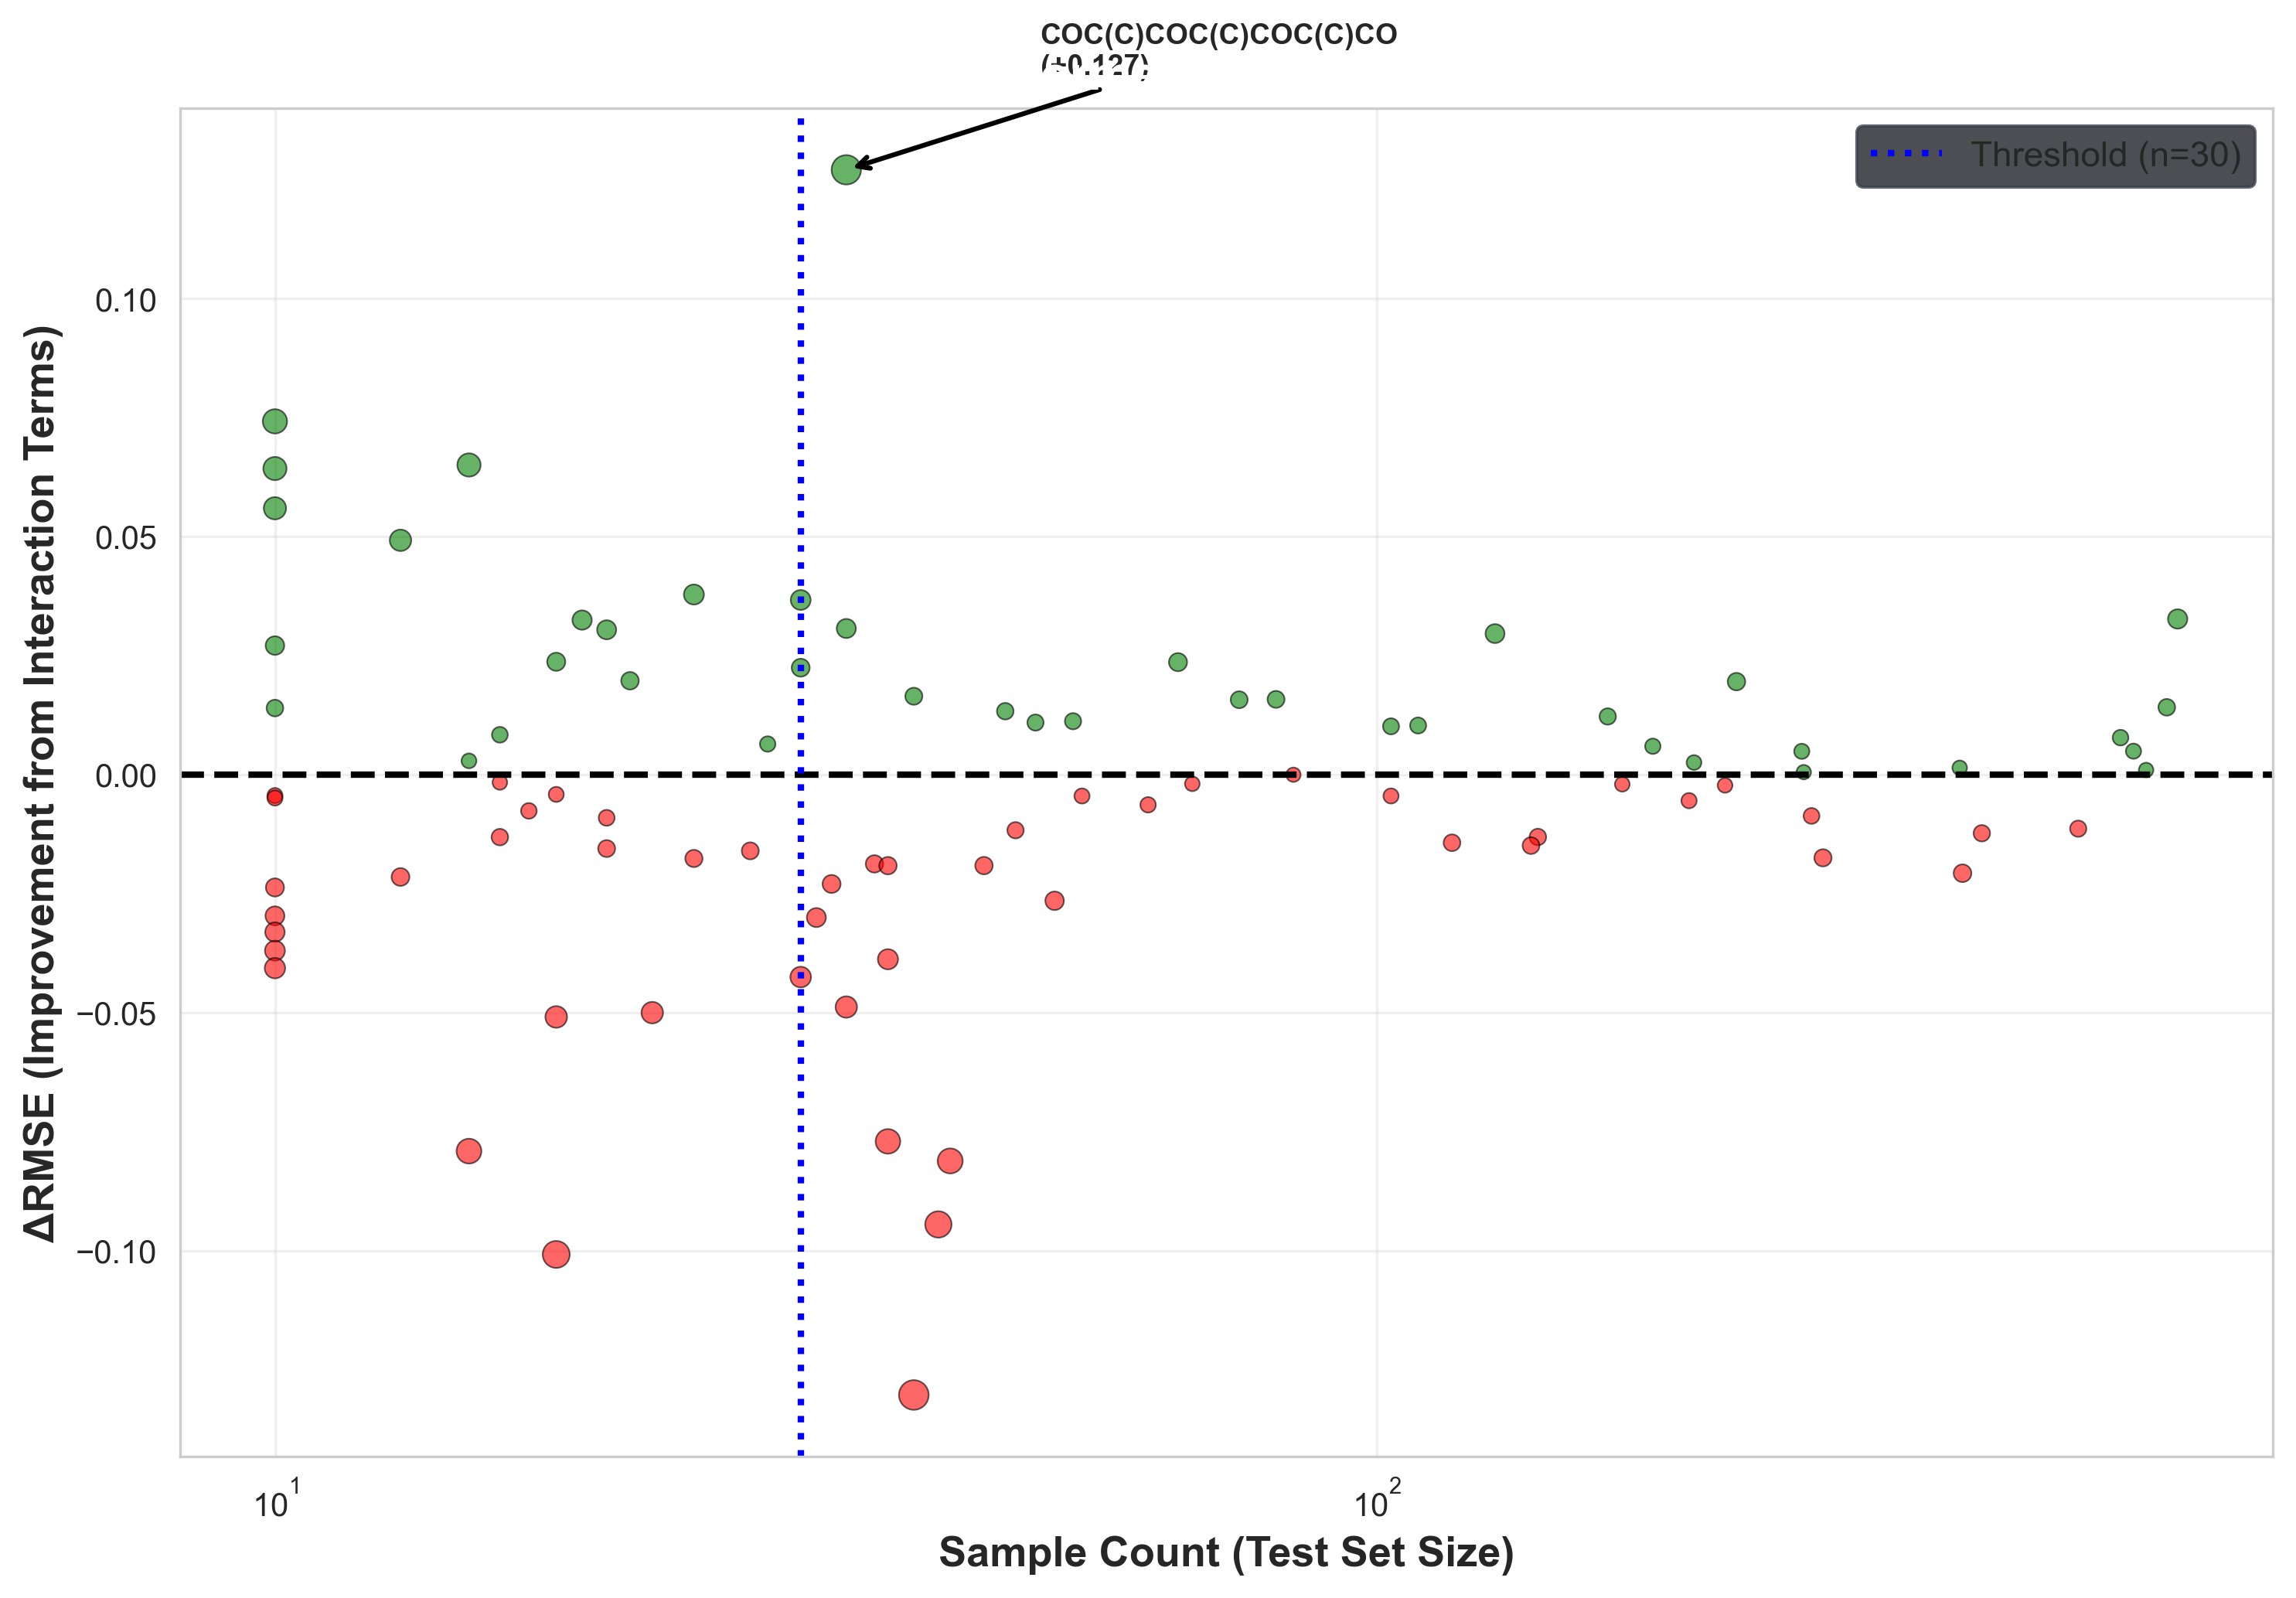

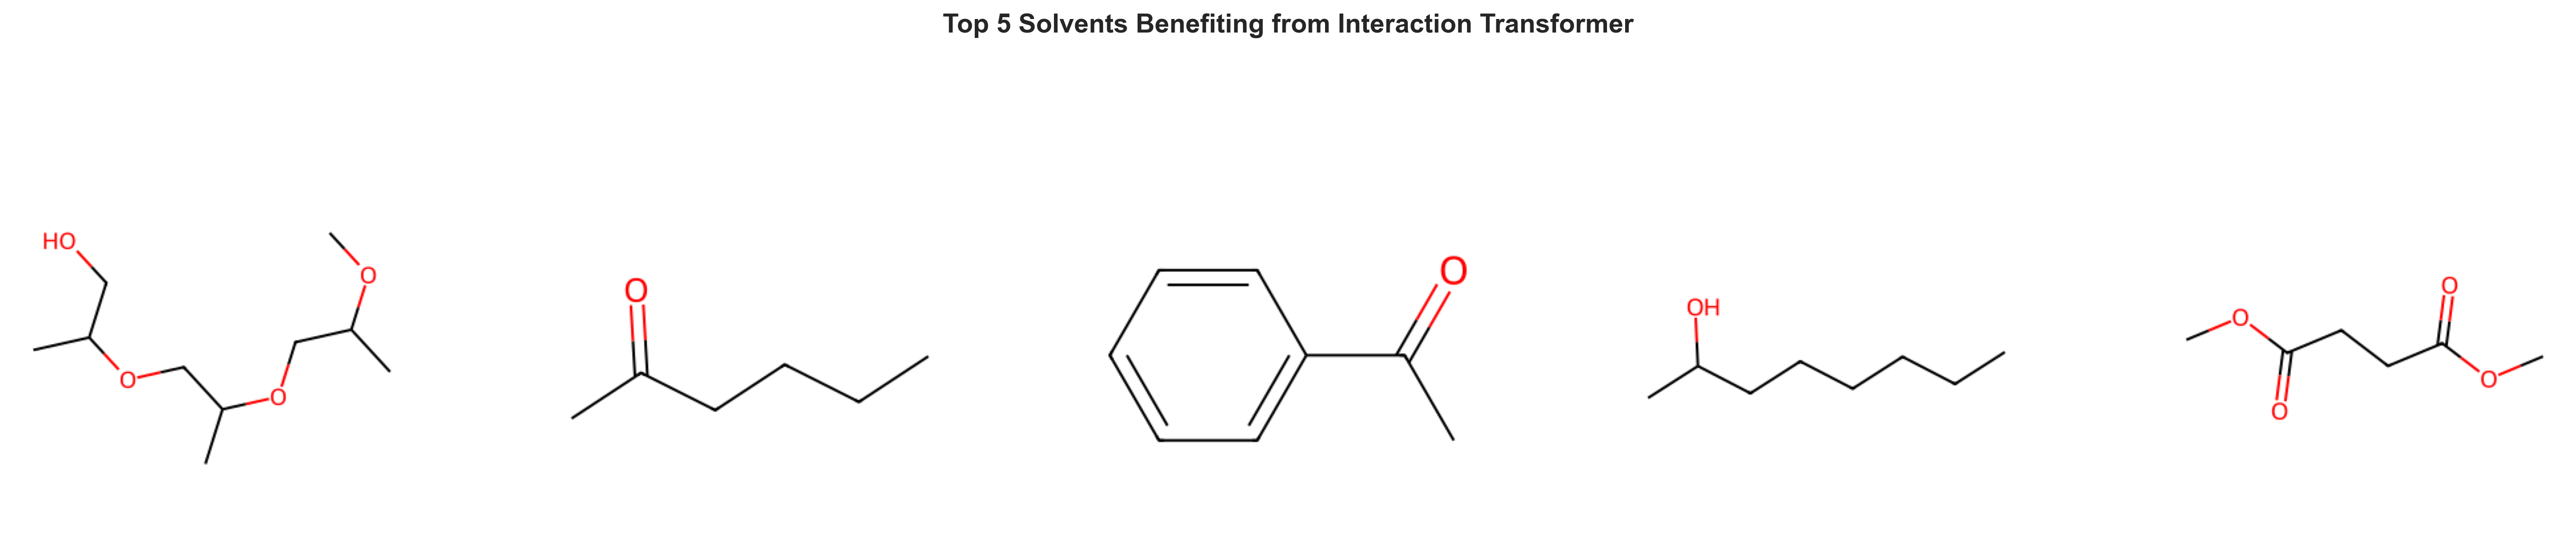

In [4]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, ttest_ind, wilcoxon
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Draw, AllChem

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300

# Load data
df = pd.read_csv('solvent_interaction_analysis_results.csv')

print("="*80)
print("TRANSFORMER BENEFIT CASE ANALYSIS")
print("="*80)

# ============================================================================
# ANGLE 1: Data-Scarce Solvents (Rare Solvent Safety Net)
# ============================================================================

print("\n" + "="*80)
print("ANGLE 1: DATA-SCARCE SOLVENTS")
print("="*80)

# Define threshold
threshold = 30

small_sample = df[df['Count'] <= threshold]
large_sample = df[df['Count'] > threshold]

print(f"\nSmall sample solvents (Count ≤ {threshold}): n = {len(small_sample)}")
print(f"  Mean ΔRMSE: {small_sample['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {small_sample['Delta_RMSE'].median():.6f}")
print(f"  Std ΔRMSE: {small_sample['Delta_RMSE'].std():.6f}")

print(f"\nLarge sample solvents (Count > {threshold}): n = {len(large_sample)}")
print(f"  Mean ΔRMSE: {large_sample['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {large_sample['Delta_RMSE'].median():.6f}")
print(f"  Std ΔRMSE: {large_sample['Delta_RMSE'].std():.6f}")

# Statistical test
stat_mw, p_mw = mannwhitneyu(small_sample['Delta_RMSE'], 
                              large_sample['Delta_RMSE'], 
                              alternative='greater')
print(f"\nMann-Whitney U test (small > large): U = {stat_mw:.2f}, p = {p_mw:.4f}")

# T-test as well
stat_t, p_t = ttest_ind(small_sample['Delta_RMSE'], 
                         large_sample['Delta_RMSE'])
print(f"Independent t-test: t = {stat_t:.3f}, p = {p_t:.4f}")

# Count positive improvements
small_positive = (small_sample['Delta_RMSE'] > 0).sum()
large_positive = (large_sample['Delta_RMSE'] > 0).sum()
print(f"\nPositive improvements (ΔRMSE > 0):")
print(f"  Small sample: {small_positive}/{len(small_sample)} ({100*small_positive/len(small_sample):.1f}%)")
print(f"  Large sample: {large_positive}/{len(large_sample)} ({100*large_positive/len(large_sample):.1f}%)")

# ============================================================================
# ANGLE 2: Multifunctional Solvents
# ============================================================================

print("\n" + "="*80)
print("ANGLE 2: MULTIFUNCTIONAL SOLVENTS")
print("="*80)

# Count functional groups (simple heuristic: count of O, N, S, halogens)
def count_heteroatoms_simple(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 0
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() in ['O', 'N', 'S', 'F', 'Cl', 'Br', 'I'])

df['n_heteroatoms_simple'] = df['Solvent'].apply(count_heteroatoms_simple)

# Define multifunctional as having 3+ heteroatoms
multifunctional = df[df['n_heteroatoms_simple'] >= 3]
simple = df[df['n_heteroatoms_simple'] < 3]

print(f"\nMultifunctional solvents (≥3 heteroatoms): n = {len(multifunctional)}")
print(f"  Mean ΔRMSE: {multifunctional['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {multifunctional['Delta_RMSE'].median():.6f}")

print(f"\nSimple solvents (<3 heteroatoms): n = {len(simple)}")
print(f"  Mean ΔRMSE: {simple['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {simple['Delta_RMSE'].median():.6f}")

stat_mw2, p_mw2 = mannwhitneyu(multifunctional['Delta_RMSE'], 
                                simple['Delta_RMSE'], 
                                alternative='greater')
print(f"\nMann-Whitney U test (multifunctional > simple): U = {stat_mw2:.2f}, p = {p_mw2:.4f}")

# Show top multifunctional improvers
print("\nTop 5 Multifunctional Improvers:")
top_multifunc = multifunctional.nlargest(5, 'Delta_RMSE')[
    ['Name', 'Solvent', 'Delta_RMSE', 'Pct_Improvement', 'n_heteroatoms_simple', 'Count']
]
print(top_multifunc.to_string(index=False))

# ============================================================================
# ANGLE 3: High-Error Rescue Mechanism
# ============================================================================

print("\n" + "="*80)
print("ANGLE 3: HIGH-ERROR RESCUE MECHANISM")
print("="*80)

# Define "difficult" as baseline RMSE above median or 75th percentile
percentile_75 = df['RMSE_Without'].quantile(0.75)
median_rmse = df['RMSE_Without'].median()

difficult = df[df['RMSE_Without'] > percentile_75]
easy = df[df['RMSE_Without'] <= percentile_75]

print(f"\nDifficult solvents (RMSE_Without > {percentile_75:.3f}): n = {len(difficult)}")
print(f"  Mean baseline RMSE: {difficult['RMSE_Without'].mean():.4f}")
print(f"  Mean ΔRMSE: {difficult['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {difficult['Delta_RMSE'].median():.6f}")

print(f"\nEasy solvents (RMSE_Without ≤ {percentile_75:.3f}): n = {len(easy)}")
print(f"  Mean baseline RMSE: {easy['RMSE_Without'].mean():.4f}")
print(f"  Mean ΔRMSE: {easy['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {easy['Delta_RMSE'].median():.6f}")

stat_mw3, p_mw3 = mannwhitneyu(difficult['Delta_RMSE'], 
                                easy['Delta_RMSE'], 
                                alternative='greater')
print(f"\nMann-Whitney U test (difficult > easy): U = {stat_mw3:.2f}, p = {p_mw3:.4f}")

# Absolute error reduction
difficult['absolute_improvement'] = difficult['RMSE_Without'] - difficult['RMSE_With']
easy['absolute_improvement'] = easy['RMSE_Without'] - easy['RMSE_With']

print(f"\nAbsolute RMSE reduction:")
print(f"  Difficult solvents: {difficult['absolute_improvement'].mean():.6f}")
print(f"  Easy solvents: {easy['absolute_improvement'].mean():.6f}")

# ============================================================================
# ANGLE 4: Combined Analysis - Small Sample + Multifunctional
# ============================================================================

print("\n" + "="*80)
print("ANGLE 4: COMBINED - SMALL SAMPLE + MULTIFUNCTIONAL")
print("="*80)

# The sweet spot: small sample AND multifunctional
sweet_spot = df[(df['Count'] <= threshold) & (df['n_heteroatoms_simple'] >= 3)]
others = df[~((df['Count'] <= threshold) & (df['n_heteroatoms_simple'] >= 3))]

print(f"\nSweet spot (small sample + multifunctional): n = {len(sweet_spot)}")
print(f"  Mean ΔRMSE: {sweet_spot['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {sweet_spot['Delta_RMSE'].median():.6f}")

print(f"\nAll other solvents: n = {len(others)}")
print(f"  Mean ΔRMSE: {others['Delta_RMSE'].mean():.6f}")
print(f"  Median ΔRMSE: {others['Delta_RMSE'].median():.6f}")

if len(sweet_spot) > 0:
    stat_mw4, p_mw4 = mannwhitneyu(sweet_spot['Delta_RMSE'], 
                                    others['Delta_RMSE'], 
                                    alternative='greater')
    print(f"\nMann-Whitney U test (sweet spot > others): U = {stat_mw4:.2f}, p = {p_mw4:.4f}")

# ============================================================================
# VISUALIZATION 1: Three-Panel Benefit Analysis
# ============================================================================

print("\n" + "="*80)
print("GENERATING VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: Data-scarce vs data-rich
ax = axes[0]
box_data = [small_sample['Delta_RMSE'].dropna(), large_sample['Delta_RMSE'].dropna()]
bp = ax.boxplot(box_data, labels=[f'Data-Scarce\n(n≤{threshold})', f'Data-Rich\n(n>{threshold})'],
                patch_artist=True, showmeans=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_ylabel('ΔRMSE (Improvement)', fontsize=12, fontweight='bold')
ax.set_title(f'A) Data-Scarce Benefit\n(p = {p_mw:.3f})', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel B: Multifunctional vs simple
ax = axes[1]
box_data2 = [multifunctional['Delta_RMSE'].dropna(), simple['Delta_RMSE'].dropna()]
bp2 = ax.boxplot(box_data2, labels=['Multifunctional\n(≥3 heteroatoms)', 'Simple\n(<3 heteroatoms)'],
                 patch_artist=True, showmeans=True)
bp2['boxes'][0].set_facecolor('lightgreen')
bp2['boxes'][1].set_facecolor('lightgray')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_ylabel('ΔRMSE (Improvement)', fontsize=12, fontweight='bold')
ax.set_title(f'B) Multifunctional Benefit\n(p = {p_mw2:.3f})', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Panel C: High-error rescue
ax = axes[2]
box_data3 = [difficult['Delta_RMSE'].dropna(), easy['Delta_RMSE'].dropna()]
bp3 = ax.boxplot(box_data3, labels=[f'Difficult\n(RMSE>{percentile_75:.2f})', f'Easy\n(RMSE≤{percentile_75:.2f})'],
                 patch_artist=True, showmeans=True)
bp3['boxes'][0].set_facecolor('orange')
bp3['boxes'][1].set_facecolor('lightblue')
ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.7)
ax.set_ylabel('ΔRMSE (Improvement)', fontsize=12, fontweight='bold')
ax.set_title(f'C) Error Rescue Effect\n(p = {p_mw3:.3f})', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('transformer_benefit_analysis.png', dpi=300, bbox_inches='tight')
print("Saved: transformer_benefit_analysis.png")

# ============================================================================
# VISUALIZATION 2: Scatter Plot - Sample Count vs ΔRMSE
# ============================================================================

fig, ax = plt.subplots(figsize=(10, 7))

# Color by whether improvement is positive or negative
colors = ['green' if x > 0 else 'red' for x in df['Delta_RMSE']]
sizes = np.abs(df['Delta_RMSE']) * 500 + 20  # Size proportional to magnitude

ax.scatter(df['Count'], df['Delta_RMSE'], c=colors, s=sizes, alpha=0.6, 
           edgecolors='black', linewidth=0.5)
ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
ax.axvline(x=threshold, color='blue', linestyle=':', linewidth=2, 
           label=f'Threshold (n={threshold})')

ax.set_xlabel('Sample Count (Test Set Size)', fontsize=13, fontweight='bold')
ax.set_ylabel('ΔRMSE (Improvement from Interaction Terms)', fontsize=13, fontweight='bold')
ax.set_title('Interaction Transformer Benefit vs. Data Availability', fontsize=15, fontweight='bold')
ax.set_xscale('log')
ax.grid(alpha=0.3)
ax.legend(fontsize=11)

# Add annotation for best improver
best_idx = df['Delta_RMSE'].idxmax()
best_row = df.loc[best_idx]
ax.annotate(f"{best_row['Name']}\n(+{best_row['Delta_RMSE']:.3f})", 
            xy=(best_row['Count'], best_row['Delta_RMSE']),
            xytext=(best_row['Count']*1.5, best_row['Delta_RMSE']+0.02),
            arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
            fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('sample_count_vs_improvement.png', dpi=300, bbox_inches='tight')
print("Saved: sample_count_vs_improvement.png")

# ============================================================================
# VISUALIZATION 3: Top Improvers with Molecular Structures
# ============================================================================

print("\nGenerating molecular structure figure...")

top_5 = df.nlargest(5, 'Delta_RMSE')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for idx, (i, row) in enumerate(top_5.iterrows()):
    mol = Chem.MolFromSmiles(row['Solvent'])
    if mol is not None:
        img = Draw.MolToImage(mol, size=(300, 300))
        axes[idx].imshow(img)
        axes[idx].axis('off')
        axes[idx].set_title(f"{row['Name'][:15]}\nΔRMSE: +{row['Delta_RMSE']:.3f}\n"
                           f"({row['Pct_Improvement']:.1f}% improvement)\n"
                           f"Heteroatoms: {row['n_heteroatoms_simple']}, n={row['Count']}",
                           fontsize=10, fontweight='bold')

plt.suptitle('Top 5 Solvents Benefiting from Interaction Transformer', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('top_improver_structures.png', dpi=300, bbox_inches='tight')
print("Saved: top_improver_structures.png")

# ============================================================================
# SUMMARY TABLE FOR PAPER
# ============================================================================

print("\n" + "="*80)
print("SUMMARY TABLE (LaTeX)")
print("="*80)

latex_table = r"""
\begin{table}[htbp]
\centering
\caption{Transformer Benefit Across Different Solvent Regimes}
\label{tab:transformer_regimes}
\begin{tabular}{lcccc}
\toprule
Regime & N & Mean $\Delta$RMSE & Median $\Delta$RMSE & p-value \\
       & Solvents & (logS) & (logS) & (vs. complement) \\
\midrule
"""

# Add rows
regimes = [
    ("Data-Scarce (n≤30)", len(small_sample), small_sample['Delta_RMSE'].mean(), 
     small_sample['Delta_RMSE'].median(), p_mw),
    ("Data-Rich (n>30)", len(large_sample), large_sample['Delta_RMSE'].mean(), 
     large_sample['Delta_RMSE'].median(), None),
    ("Multifunctional (≥3 heteroatoms)", len(multifunctional), multifunctional['Delta_RMSE'].mean(),
     multifunctional['Delta_RMSE'].median(), p_mw2),
    ("Simple (<3 heteroatoms)", len(simple), simple['Delta_RMSE'].mean(),
     simple['Delta_RMSE'].median(), None),
    ("Difficult (high baseline error)", len(difficult), difficult['Delta_RMSE'].mean(),
     difficult['Delta_RMSE'].median(), p_mw3),
    ("Easy (low baseline error)", len(easy), easy['Delta_RMSE'].mean(),
     easy['Delta_RMSE'].median(), None),
]

for name, n, mean_val, median_val, p_val in regimes:
    p_str = f"{p_val:.3f}" if p_val is not None else "—"
    latex_table += f"{name} & {n} & {mean_val:+.4f} & {median_val:+.4f} & {p_str} \\\\\n"

latex_table += r"""\bottomrule
\end{tabular}
\end{table}
"""

print(latex_table)

with open('transformer_regimes_table.tex', 'w') as f:
    f.write(latex_table)
print("\nSaved: transformer_regimes_table.tex")

# ============================================================================
# EXPORT ENHANCED DATASET
# ============================================================================

df['data_scarce'] = df['Count'] <= threshold
df['multifunctional'] = df['n_heteroatoms_simple'] >= 3
df['difficult'] = df['RMSE_Without'] > percentile_75

df_export = df[[
    'Solvent', 'Name', 'Polarity', 'Count',
    'RMSE_With', 'RMSE_Without', 'Delta_RMSE', 'Pct_Improvement',
    'n_heteroatoms_simple', 'data_scarce', 'multifunctional', 'difficult'
]]

df_export.to_csv('transformer_analysis_enhanced.csv', index=False)
print("\nSaved: transformer_analysis_enhanced.csv")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("ANALYSIS COMPLETE - KEY FINDINGS")
print("="*80)

print("\n✓ ANGLE 1 (Data-Scarce): ", end="")
if p_mw < 0.05:
    print(f"SIGNIFICANT (p={p_mw:.3f}) ✓✓✓")
else:
    print(f"NOT SIGNIFICANT (p={p_mw:.3f})")

print("✓ ANGLE 2 (Multifunctional): ", end="")
if p_mw2 < 0.05:
    print(f"SIGNIFICANT (p={p_mw2:.3f}) ✓✓✓")
else:
    print(f"NOT SIGNIFICANT (p={p_mw2:.3f})")

print("✓ ANGLE 3 (High-Error Rescue): ", end="")
if p_mw3 < 0.05:
    print(f"SIGNIFICANT (p={p_mw3:.3f}) ✓✓✓")
else:
    print(f"NOT SIGNIFICANT (p={p_mw3:.3f})")

print("\n" + "="*80)
print("GENERATED FILES:")
print("  1. transformer_benefit_analysis.png (3-panel comparison)")
print("  2. sample_count_vs_improvement.png (scatter plot)")
print("  3. top_improver_structures.png (molecular structures)")
print("  4. transformer_regimes_table.tex (LaTeX table)")
print("  5. transformer_analysis_enhanced.csv (enhanced data)")
print("="*80)